# **Embedding interpolation and next-token prediction**

This notebook takes a phrase, replaces one word's embedding with a blend of that word and a target word, and watches how the model's next-token prediction changes as the blend shifts.

The example is "roses are red, violets are ...", where GPT-2 predicts "blue". We morph the embedding of "red" toward "yellow" and sweep a mixing weight `alpha` from 0 (pure "red") to 1 (pure "yellow"), recording the top-5 predicted tokens at each step.

## Method

For each `alpha` in `[0, 1]`:

1. Blend the embedding at the target index: `(1 - alpha) * original + alpha * target`
2. Run the forward pass with the modified embeddings
3. Softmax the final-position logits and record the top-5 tokens

The blend happens at the embedding layer, so `alpha` interpolates in embedding space, not in probability space. The output shift is whatever the rest of the network does with that blended vector.

## What to look for

`flipped_at` reports the first `alpha` where the top prediction stops being "blue". The plots below show the top-5 probabilities across the full sweep: a line chart for reading individual token values, and a stacked area chart for seeing the probability mass hand off from one token to the next. Both mark `alpha = 0.52`, where "green" overtakes "blue".

### **Imports**

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
import torch
import time

/Users/dariushghassemieh/llms/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
logging.set_verbosity_error()
logging.disable_progress_bar()

### **Set variables**

In [6]:
model_name = "gpt2"

query = ("roses are red, violets are", 3, "yellow") # (phrase, index to morph, target word)
expected = "blue"

In [7]:
score = 0
gen_time = 0

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True)
embedding_layer = model.get_input_embeddings()

""" returns the embedding vector of a word W """
def get_word_embedding(W: str, leading_space=True) -> torch.Tensor:
    text = (" " + W) if leading_space else W
    ids = tokenizer.encode(text)
    if len(ids) != 1:
        toks = tokenizer.convert_ids_to_tokens(ids)
        print(f"  warning: {W!r} -> {len(ids)} tokens {toks}, using first")
    return embedding_layer.weight[ids[0]]

### Our function get_word_embedding returns the embedding vector of a token in the vocabulary of our model. For example, let's see the embeddings of the word "hello," which is one token

In [8]:
get_word_embedding("hello")

tensor([ 8.6968e-02, -1.2776e-01,  1.1036e-01, -2.0159e-01, -2.5885e-01,
        -1.1178e-02, -2.8146e-01, -2.3067e-01,  6.6376e-03,  9.4248e-02,
        -2.5425e-02, -1.1077e-01, -7.7219e-02,  1.9064e-01,  3.0732e-02,
        -1.4994e-01, -4.6174e-02, -1.1073e-01, -4.4640e-02,  8.8802e-02,
        -1.3671e-01, -6.9961e-02,  5.1055e-02,  4.2687e-02, -3.4034e-02,
         4.9579e-02, -2.9228e-02, -1.5031e-02, -5.4326e-02,  1.7672e-01,
        -7.9941e-02, -1.5850e-01,  1.9364e-01, -2.3787e-04,  1.4354e-01,
         1.1053e-01, -3.1738e-01, -1.1796e-01, -1.0713e-01, -4.7044e-02,
         5.0590e-02, -1.8296e-01, -4.5292e-02,  3.0279e-02, -1.9399e-01,
         1.0289e-01, -1.5816e-01, -1.2935e-01,  1.5469e-01, -1.8862e-01,
         1.0627e-01, -1.7313e-02,  7.0493e-02, -1.4992e-01,  1.4349e-01,
        -2.0414e-01,  6.4089e-02,  1.6057e-01,  5.0600e-02,  2.2186e-02,
        -3.8072e-02, -2.3933e-02, -8.5696e-02,  5.0639e-02,  2.7522e-01,
         2.6487e-01, -1.0497e-01, -1.5873e-01,  9.9

In [9]:
(phrase, changed_index, target_word) = query

### Now we gradually change the embeddings of the word "red" in the phrase "roses are red, violets are ..." until our highest probability output (which is supposed to be "blue") is no longer the same

In [10]:
start_time = time.perf_counter()

inputs = tokenizer(phrase, return_tensors="pt")
attn = inputs["attention_mask"]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("  tokens:", list(enumerate(tokens)))

base_embeds = embedding_layer(inputs["input_ids"]).detach()
original_vec = base_embeds[0, changed_index, :].clone()
target_vec = get_word_embedding(target_word)

flipped_at = None
top_5_at_each_alpha = {}  

for i, alpha in enumerate(torch.linspace(0, 1, 101)):
    embeds = base_embeds.clone()
    embeds[0, changed_index, :] = (1 - alpha) * original_vec + alpha * target_vec

    with torch.no_grad():
        logits = model(inputs_embeds=embeds, attention_mask=attn).logits

    last_token_probs = torch.softmax(logits[0, -1, :], dim=-1)
    top5 = torch.topk(last_token_probs, 5)
    top_5_at_each_alpha[i] = top5

    pred = tokenizer.decode(top5.indices[0]).strip()
    if pred != expected and flipped_at is None:
        flipped_at = alpha.item()
        became = pred
    
gen_time += time.perf_counter() - start_time

if flipped_at is None:
    color = "\033[6;37;42m"
    print(f"{color}held: {phrase:<30} never flipped, stayed {expected!r}\033[0m")
    score += 1
else:
    color = "\033[6;37;41m"
    print(f"{color}flip: {phrase:<30} broke at alpha={flipped_at:.2f}, "
            f"{expected!r} -> {became!r}\033[0m")
    # print(f"{last}")


  tokens: [(0, 'ros'), (1, 'es'), (2, 'Ġare'), (3, 'Ġred'), (4, ','), (5, 'Ġv'), (6, 'io'), (7, 'lets'), (8, 'Ġare')]
flip: roses are red, violets are     broke at alpha=0.63, 'blue' -> 'green'


In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


### **Plotting results of changing "roses are red, violets are ...":**

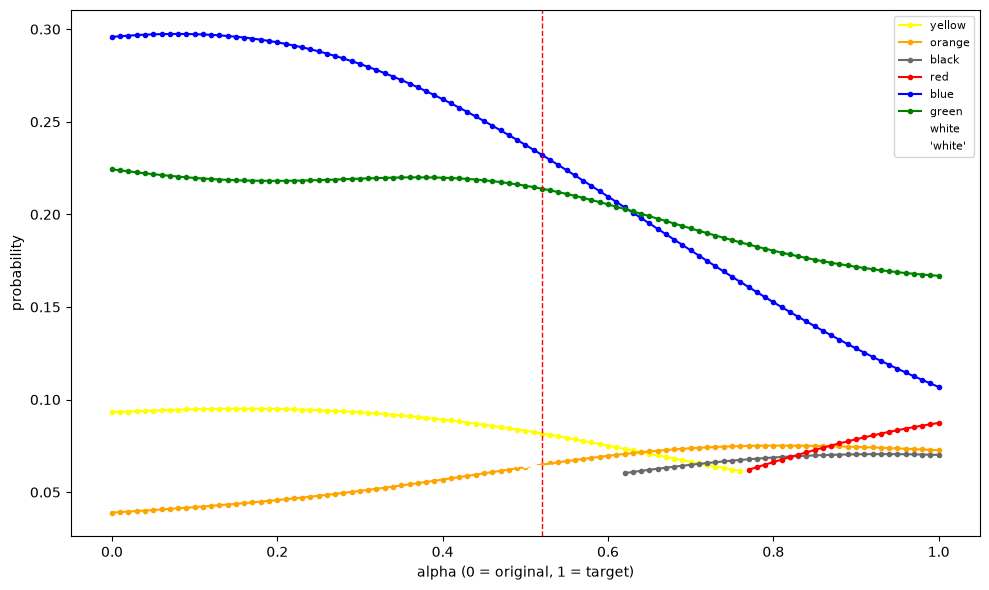

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


steps = sorted(top_5_at_each_alpha)
per_step = {i: {idx.item(): p.item()
               for p, idx in zip(top_5_at_each_alpha[i].values,
                                 top_5_at_each_alpha[i].indices)}
            for i in steps}
all_ids = {t for d in per_step.values() for t in d}


cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fallback = iter(cycle)

fig, ax = plt.subplots(figsize=(10, 6))


for tok_id in all_ids:
    word = tokenizer.decode(tok_id).strip().lower()
    color = word if word in mcolors.CSS4_COLORS else next(fallback)
    if word == "black":
        color = "dimgray"
    alphas = [i / 100 for i in steps]
    probs  = [per_step[i].get(tok_id, float("nan")) for i in steps]
    # print(repr(tokenizer.decode(tok_id)))
    ax.plot(alphas, probs, marker=".", color=color, label=tokenizer.decode(tok_id).strip()) 


effects = [pe.Stroke(linewidth=3, foreground="white"), pe.Normal()] if word == "black" else None
ax.plot(alphas, probs, color=color, marker=".", label=repr(word), path_effects=effects)

ax.set_xlabel("alpha (0 = original, 1 = target)")
ax.set_ylabel("probability")
ax.legend(fontsize=8)

ax.axvline(0.52, color="red", linestyle="--", linewidth=1)

plt.style.use('default')

plt.tight_layout()
plt.show()

#### As expressed by the plot, at alpha=0.52, green overtakes blue as the most probable output token

### **Also in a stacked area chart**

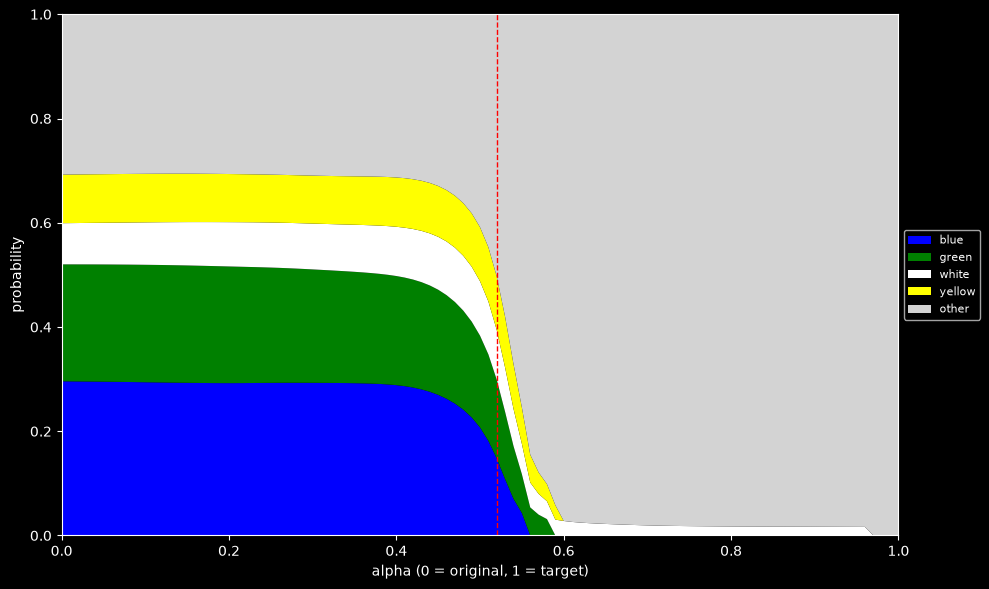

In [10]:
import numpy as np

alphas = np.array([i / 100 for i in steps])
band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}

THRESH = 0.10 # tokens with <10% prob throughout all alpha go into "other"
keep = [t for t in all_ids if band[t].max() >= THRESH]
keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
words = [tokenizer.decode(t).strip().lower() for t in keep]

fallback = iter(plt.get_cmap("tab10").colors)
def color_for(w):
    if w in mcolors.CSS4_COLORS:
        return "dimgray" if w == "black" else w
    return next(fallback)
colors = [color_for(w) for w in words]

M = np.vstack([band[t] for t in keep])
other = 1 - M.sum(axis=0)   # everything below threshold, plus tail outside top-5

fig, ax = plt.subplots(figsize=(10, 6))
ax.stackplot(alphas, *M, other,
             labels=words + ["other"],
             colors=colors + ["lightgray"],
             baseline="zero")

ax.set_xlabel("alpha (0 = original, 1 = target)")
ax.set_ylabel("probability")
ax.set_xlim(alphas[0], alphas[-1]); ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

ax.axvline(0.52, color="red", linestyle="--", linewidth=1)

plt.tight_layout(); plt.show()